In [9]:
import numpy as np
import pandas as pd
import multiprocessing as mp
from inspect import signature
from matplotlib import pyplot as plt
from dacbench.logger import Logger, log2dataframe, load_logs
import seaborn as sns
import glob
from plotting import plot_performance_over_time, plot_final_performance_comparison, plot_improvement_probability, plot_configuration_footprint, plot_hp_importance, plot_deepcave

In [37]:
def toDataFrame(glob_path, col_name, col_index):
    d =  [log2dataframe(load_logs(path)) for path in glob.glob(glob_path)]
    
    df = pd.DataFrame([s[col_name][col_index] for s in d]).transpose()
    df['epoch'] = df.index + 1
    df = df.melt(id_vars=['epoch'])

    return df

def toChunkedDataFrame(glob_path, col_name, col_index, chunk_size):
    d =  [log2dataframe(load_logs(path)) for path in glob.glob(glob_path)]

    df = pd.DataFrame([s[col_name][col_index] for s in d]).transpose()

    result_df = pd.DataFrame()
    for col in df.columns:
        reshaped_data = df[col].values.reshape(-1, chunk_size)
        result_df[col] = reshaped_data.mean(axis=1)

    result_df.reset_index()

    result_df['epoch'] = result_df.index + 1
    result_df = result_df.melt(id_vars=['epoch'])

    return result_df


sns.set(rc={"figure.dpi":300, 'savefig.dpi':300})
sns.set_style('whitegrid')
palette = sns.color_palette("colorblind")
palette = sns.color_palette([palette[0], palette[2], palette[1], palette[3], palette[4], palette[5]])
sns.set_palette(palette)

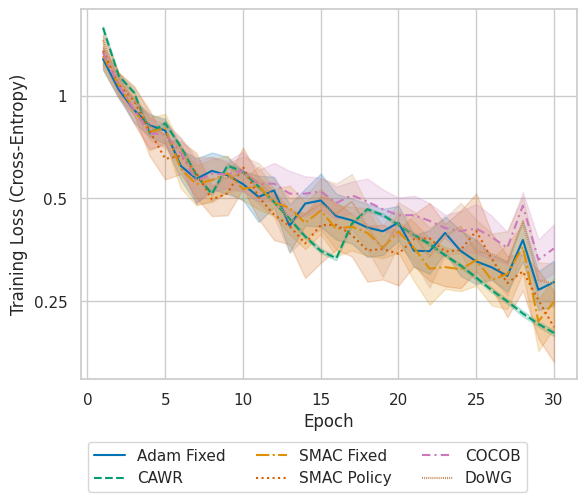

In [31]:
cocob_tl = toDataFrame('./results_cluster/results/COCOB_cifar10_30/*/CustomTrackingWrapper.jsonl', 'training_losses', 3)
# stormplus_tl = toDataFrame('./results_cluster/results/STORMplus_cifar10/*/CustomTrackingWrapper.jsonl', 'training_losses', 3)
adam_fixed_tl = toDataFrame('./results_cluster/results/Adam_fixed_cifar10_30/*/CustomTrackingWrapper.jsonl', 'training_losses', 3)
smac_fixed_tl = toDataFrame('./results_cluster/results/SMAC_fixed_cifar10_30/*/CustomTrackingWrapper.jsonl', 'training_losses', 3)
# smac_fixed_tl = smac_fixed_tl.loc[smac_fixed_tl['epoch'] <= 30]
smac_policy_tl = toDataFrame('./results_cluster/results/smacpolicy_cifar10/*/CustomTrackingWrapper.jsonl', 'training_losses', 3)
smac_policy_tl_new = toDataFrame('./results_cluster/results/smacpolicy_cifar10_new/*/CustomTrackingWrapper.jsonl', 'training_losses', 3)
dowg_tl = toDataFrame('./results_cluster/results/DoWG_cifar10_30/*/CustomTrackingWrapper.jsonl', 'training_losses', 3)
cawr_tl = toChunkedDataFrame('./results_cluster/results/CAWR_cifar10/*/CustomTrackingWrapper.jsonl', 'training_losses', 3, 625)
# sns.lineplot(data=stormplus_tl, x='epoch', y='value', label='STORMplus')
p = sns.lineplot(data=adam_fixed_tl, x='epoch', y='value', label='Adam Fixed', linestyle='solid')
sns.lineplot(data=cawr_tl, x='epoch', y='value', label='CAWR', linestyle="dashed")
sns.lineplot(data=smac_fixed_tl, x='epoch', y='value', label='SMAC Fixed', linestyle='dashdot')
sns.lineplot(data=smac_policy_tl, x='epoch', y='value', label='SMAC Policy', linestyle='dotted')
sns.lineplot(data=cocob_tl, x='epoch', y='value', label='COCOB', dashes=(4,2,1,2))
sns.lineplot(data=dowg_tl, x='epoch', y='value', label='DoWG', dashes=(0.5, 0.5))

plt.xlabel('Epoch')
plt.ylabel('Training Loss (Cross-Entropy)')
plt.yscale('log')
plt.yticks([0.25, 0.5, 1], ["0.25", "0.5", "1"])
sns.move_legend(p, 'upper left', bbox_to_anchor=(0, -0.15), ncol=3)

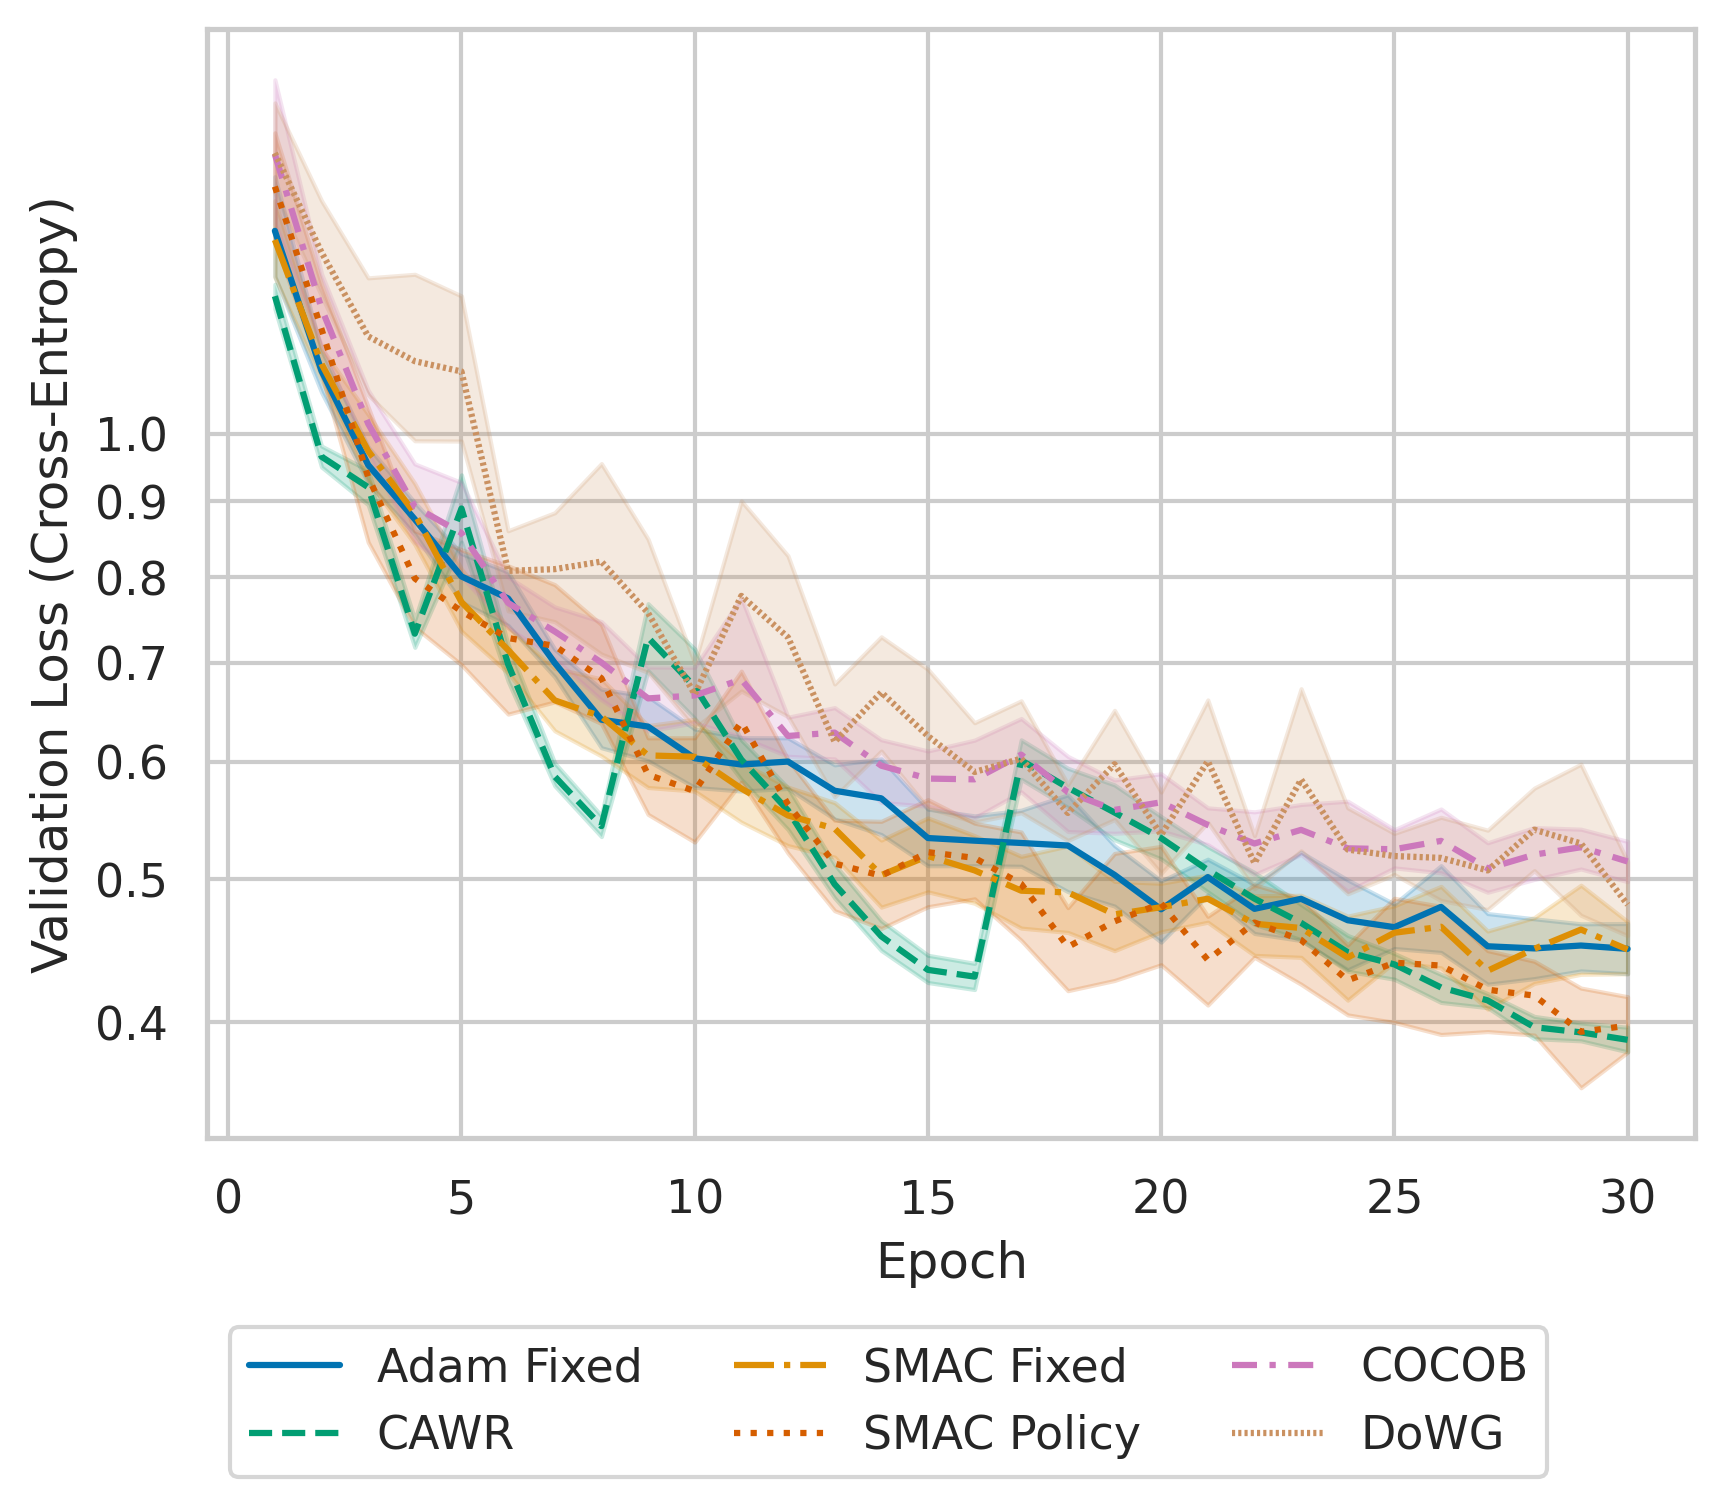

In [38]:

cocob_vl = toDataFrame('./results_cluster/results/COCOB_cifar10_30/*/CustomTrackingWrapper.jsonl', 'validation_losses', 5)
adam_fixed_vl = toDataFrame('./results_cluster/results/Adam_fixed_cifar10_30/*/CustomTrackingWrapper.jsonl', 'validation_losses', 5)
smac_fixed_vl = toDataFrame('./results_cluster/results/SMAC_fixed_cifar10_30/*/CustomTrackingWrapper.jsonl', 'validation_losses', 5)
# smac_fixed_vl= smac_fixed_vl.loc[smac_fixed_vl['epoch'] <= 30]
cawr_vl = toDataFrame('./results_cluster/results/CAWR_cifar10/*/CustomTrackingWrapper.jsonl', 'validation_losses', 5)
# cawr_vl = cawr_vl.loc[cawr_vl['epoch'] <= 30]
smac_policy_vl = toDataFrame('./results_cluster/results/smacpolicy_cifar10/*/CustomTrackingWrapper.jsonl', 'validation_losses', 5)
# smac_policy_vl_seed = toDataFrame('./results_cluster/results/smacpolicy_cifar10_same_seed/*/CustomTrackingWrapper.jsonl', 'validation_losses', 5)
dowg_vl = toDataFrame('./results_cluster/results/DoWG_cifar10_30/*/CustomTrackingWrapper.jsonl', 'validation_losses', 5)

p = sns.lineplot(data=adam_fixed_vl, x='epoch', y='value', label='Adam Fixed', linestyle='solid')
sns.lineplot(data=cawr_vl, x='epoch', y='value', label='CAWR', linestyle="dashed")
sns.lineplot(data=smac_fixed_vl, x='epoch', y='value', label='SMAC Fixed', linestyle='dashdot')
sns.lineplot(data=smac_policy_vl, x='epoch', y='value', label='SMAC Policy', linestyle='dotted')
sns.lineplot(data=cocob_vl, x='epoch', y='value', label='COCOB', dashes=(4,2,1,2))
sns.lineplot(data=dowg_vl, x='epoch', y='value', label='DoWG', dashes=(0.5, 0.5))
plt.xlabel('Epoch')
plt.ylabel('Validation Loss (Cross-Entropy)')
plt.yscale('log')
plt.yticks([0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1], ["0.4", "0.5", "0.6", "0.7", "0.8", "0.9", "1.0"])
sns.move_legend(p, 'upper left', bbox_to_anchor=(0, -0.15), ncol=3)

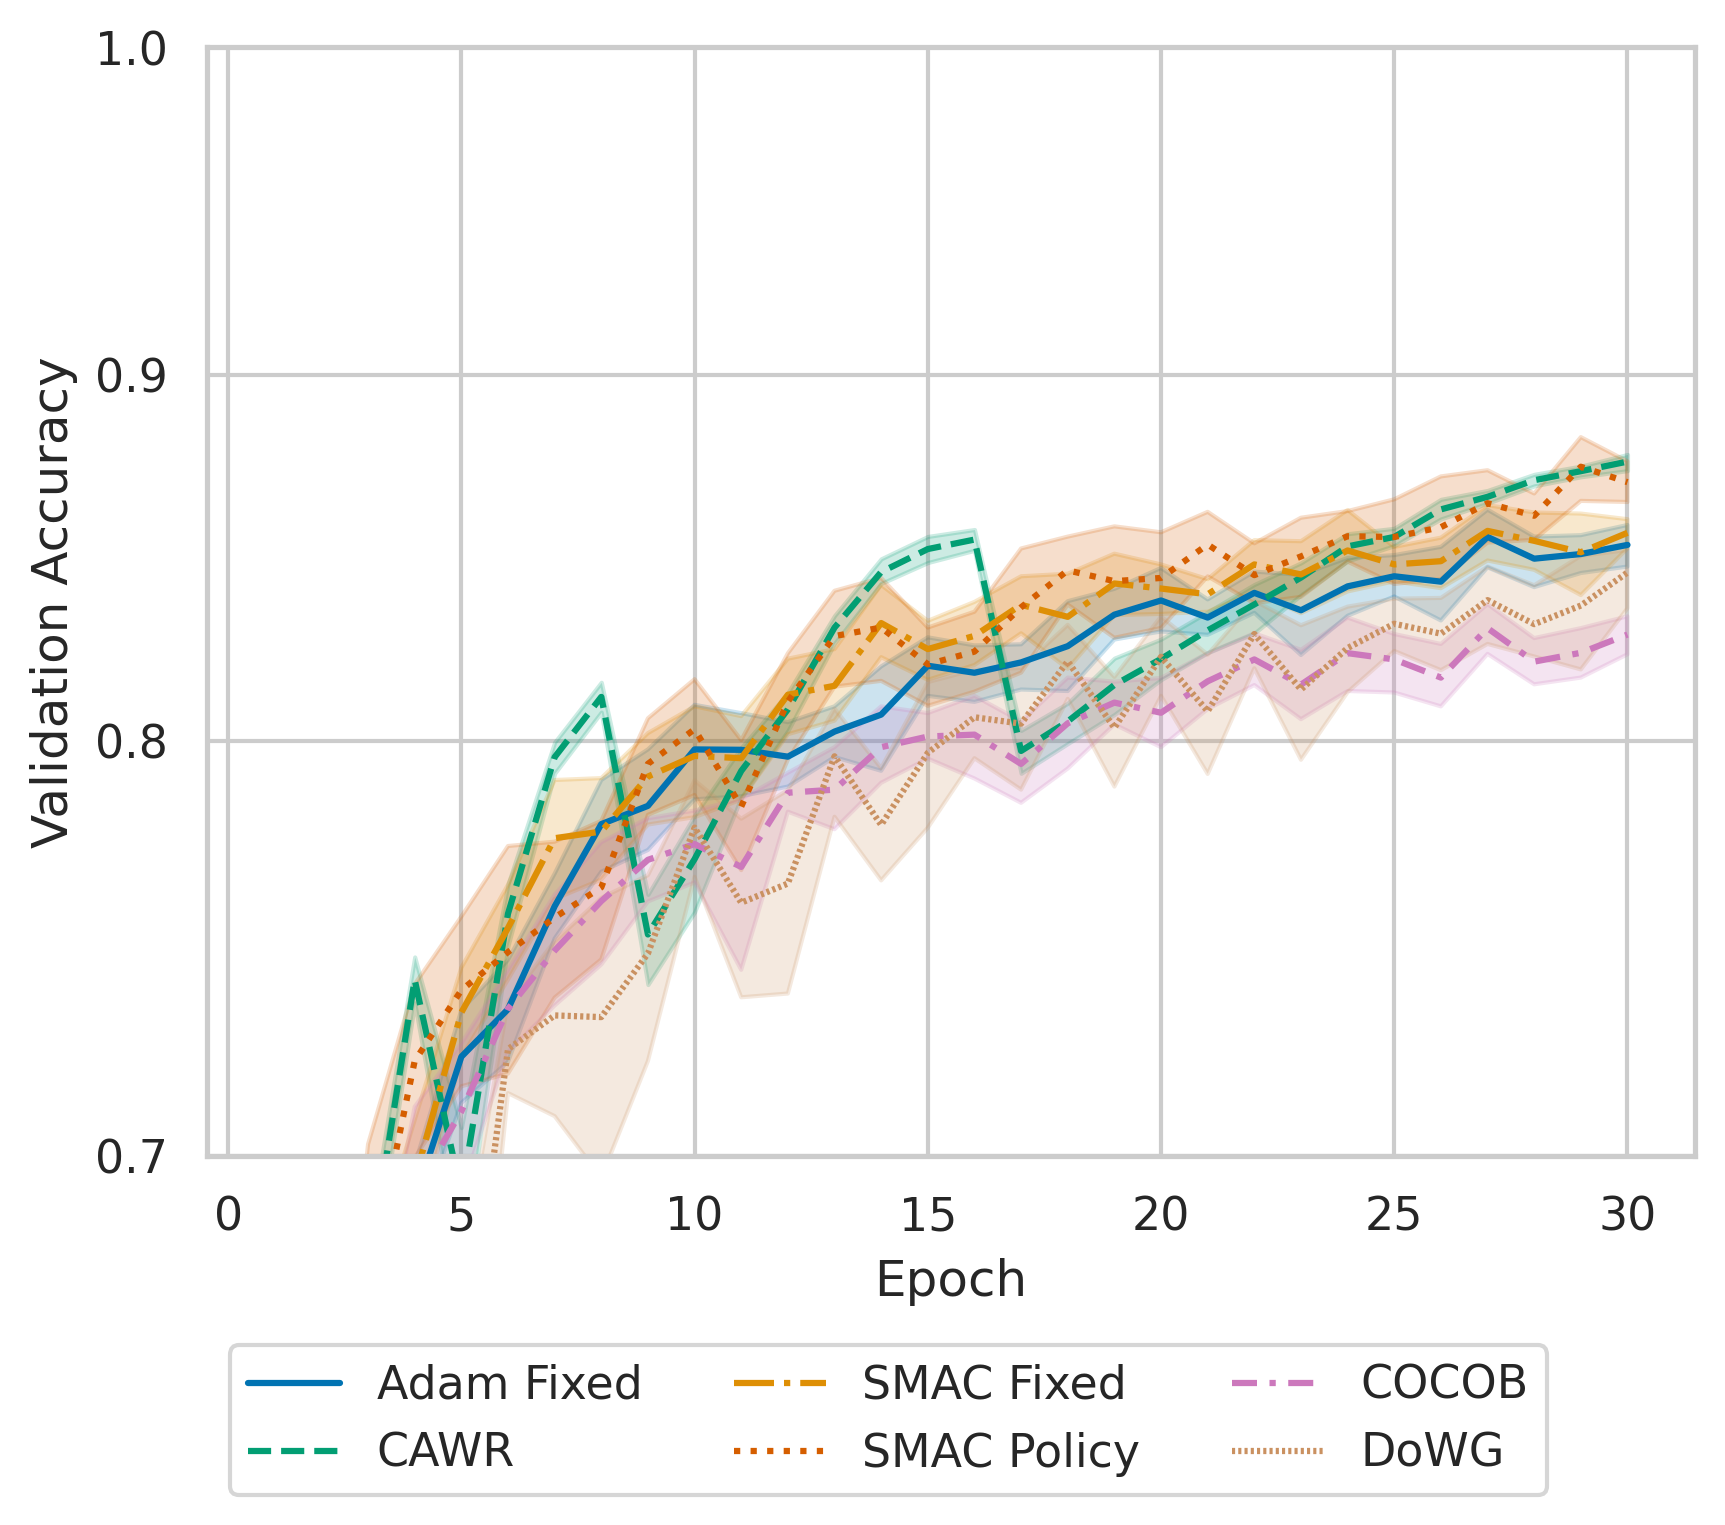

In [39]:

cocob_va = toDataFrame('./results_cluster/results/COCOB_cifar10_30/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6)
adam_fixed_va = toDataFrame('./results_cluster/results/Adam_fixed_cifar10_30/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6)
smac_fixed_va = toDataFrame('./results_cluster/results/SMAC_fixed_cifar10_30/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6)
stormplus_va = toDataFrame('./results_cluster/results/STORMplus_cifar10/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6)
# smac_fixed_va = smac_fixed_va.loc[smac_fixed_va['epoch'] <= 30]
smac_policy_va = toDataFrame('./results_cluster/results/smacpolicy_cifar10/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6)
smac_policy_va_new = toDataFrame('./results_cluster/results/smacpolicy_cifar10_new/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6)
dowg_va = toDataFrame('./results_cluster/results/DoWG_cifar10_30/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6)
cawr_va = toDataFrame('./results_cluster/results/CAWR_cifar10/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6)
# cawr_va = cawr_va.loc[cawr_va['epoch'] <= 30]
# sns.lineplot(data=stormplus_va, x='epoch', y='value', label='STORM+')
p = sns.lineplot(data=adam_fixed_va, x='epoch', y='value', label='Adam Fixed', linestyle='solid')
sns.lineplot(data=cawr_va, x='epoch', y='value', label='CAWR', linestyle="dashed")
sns.lineplot(data=smac_fixed_va, x='epoch', y='value', label='SMAC Fixed', linestyle='dashdot')
sns.lineplot(data=smac_policy_va, x='epoch', y='value', label='SMAC Policy', linestyle='dotted')
sns.lineplot(data=cocob_va, x='epoch', y='value', label='COCOB', dashes=(4,2,1,2))
sns.lineplot(data=dowg_va, x='epoch', y='value', label='DoWG', dashes=(0.5, 0.5))

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.yscale('log')
plt.ylim(0.7, 1)
plt.yticks([0.7, 0.8, 0.9, 1], ["0.7", "0.8", "0.9", "1.0"])
sns.move_legend(p, 'upper left', bbox_to_anchor=(0, -0.15), ncol=3)

Text(0, 0.5, 'Validation Accuracy')

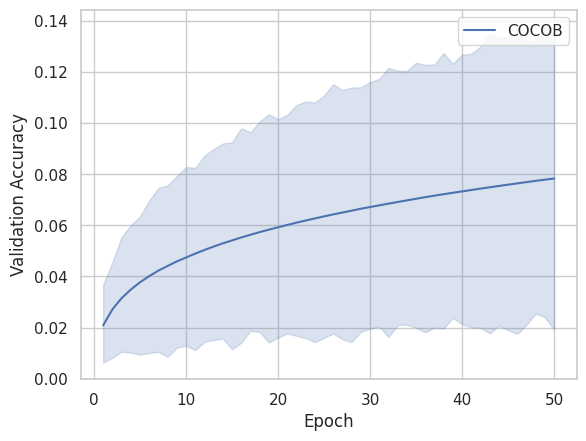

In [26]:

cocob_elr = toDataFrame('./results_cluster/results/COCOB_cifar10/*/CustomTrackingWrapper.jsonl', 'effective_lrs', 9)
sns.lineplot(data=cocob_elr, x='epoch', y='value', label='COCOB')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')